# 06 — NLP: Análise de Textos dos Santos
**Projeto: Data Science dos Santos Católicos**

**Pergunta:** *O que os textos sobre os santos revelam sobre suas espiritualidades?*

Usamos os resumos da Wikipedia de cada santo e aplicamos:
1. **Estatísticas de texto** — frequência de palavras
2. **Word Clouds** — por categoria
3. **TF-IDF** — representação vetorial dos textos
4. **LDA Topic Modeling** — descobrir tópicos temáticos latentes
5. **Análise de Sentimento** — tom dos textos por categoria
6. **t-SNE sobre texto** — visualizar similaridade textual

## Setup

In [1]:
import os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from textblob import TextBlob
from wordcloud import WordCloud

# Downloads necessários do NLTK
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

PROJECT_ROOT = Path(os.getcwd()).parent
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
FIGS         = PROJECT_ROOT / 'outputs' / 'figures'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid')

CORES_CAT = {'Martyr':'#C0392B','Confessor':'#2980B9','Doctor':'#F39C12','Virgin':'#8E44AD','Other':'#95A5A6'}

df = pd.read_csv(DATA_PROC / 'saints_clean.csv')
print(f'Dataset: {df.shape}')

Dataset: (77, 19)


## 1. Coletar Resumos da Wikipedia

Se o notebook 01 já coletou os resumos e estão em `wikipedia_summary`, usamos direto. Caso contrário, coletamos agora.

In [2]:
# Verificar se já temos resumos
if 'wikipedia_summary' in df.columns and df['wikipedia_summary'].notna().sum() > 10:
    print(f'Resumos já disponíveis: {df["wikipedia_summary"].notna().sum()} santos')
else:
    print('Coletando resumos da Wikipedia...')
    import wikipedia
    wikipedia.set_lang('en')

    summaries = []
    for nome in tqdm(df['name'], desc='Wikipedia API'):
        try:
            texto = wikipedia.summary(nome, sentences=3, auto_suggest=True)
        except Exception:
            texto = ''
        summaries.append(texto)
        import time; time.sleep(0.3)

    df['wikipedia_summary'] = summaries
    df.to_csv(DATA_PROC / 'saints_clean.csv', index=False)
    print(f'Resumos coletados: {df["wikipedia_summary"].notna().sum()}')

# Filtrar santos com texto
df_nlp = df[df['wikipedia_summary'].notna() & (df['wikipedia_summary'] != '')].copy()
df_nlp['wikipedia_summary'] = df_nlp['wikipedia_summary'].astype(str)
print(f'Santos com texto para NLP: {len(df_nlp)}')

Resumos já disponíveis: 77 santos
Santos com texto para NLP: 77


## 2. Limpeza de Texto e Estatísticas Básicas

In [3]:
STOP_EN = set(stopwords.words('english'))
STOP_EXTRA = {'saint', 'also', 'born', 'known', 'church', 'catholic', 'christian',
              'century', 'roman', 'one', 'became', 'life', 'pope', 'holy', 'new',
              'first', 'died', 'made', 'order', 'later', 'day', 'bishop'}
STOPWORDS = STOP_EN | STOP_EXTRA

def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    tokens = word_tokenize(texto)
    tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

df_nlp['texto_limpo'] = df_nlp['wikipedia_summary'].apply(limpar_texto)
df_nlp['num_palavras'] = df_nlp['texto_limpo'].apply(lambda x: len(x.split()))

print('Estatísticas dos textos:')
print(df_nlp['num_palavras'].describe().round(1))

Estatísticas dos textos:
count    77.0
mean     37.5
std       6.0
min       3.0
25%      36.0
50%      39.0
75%      41.0
max      48.0
Name: num_palavras, dtype: float64


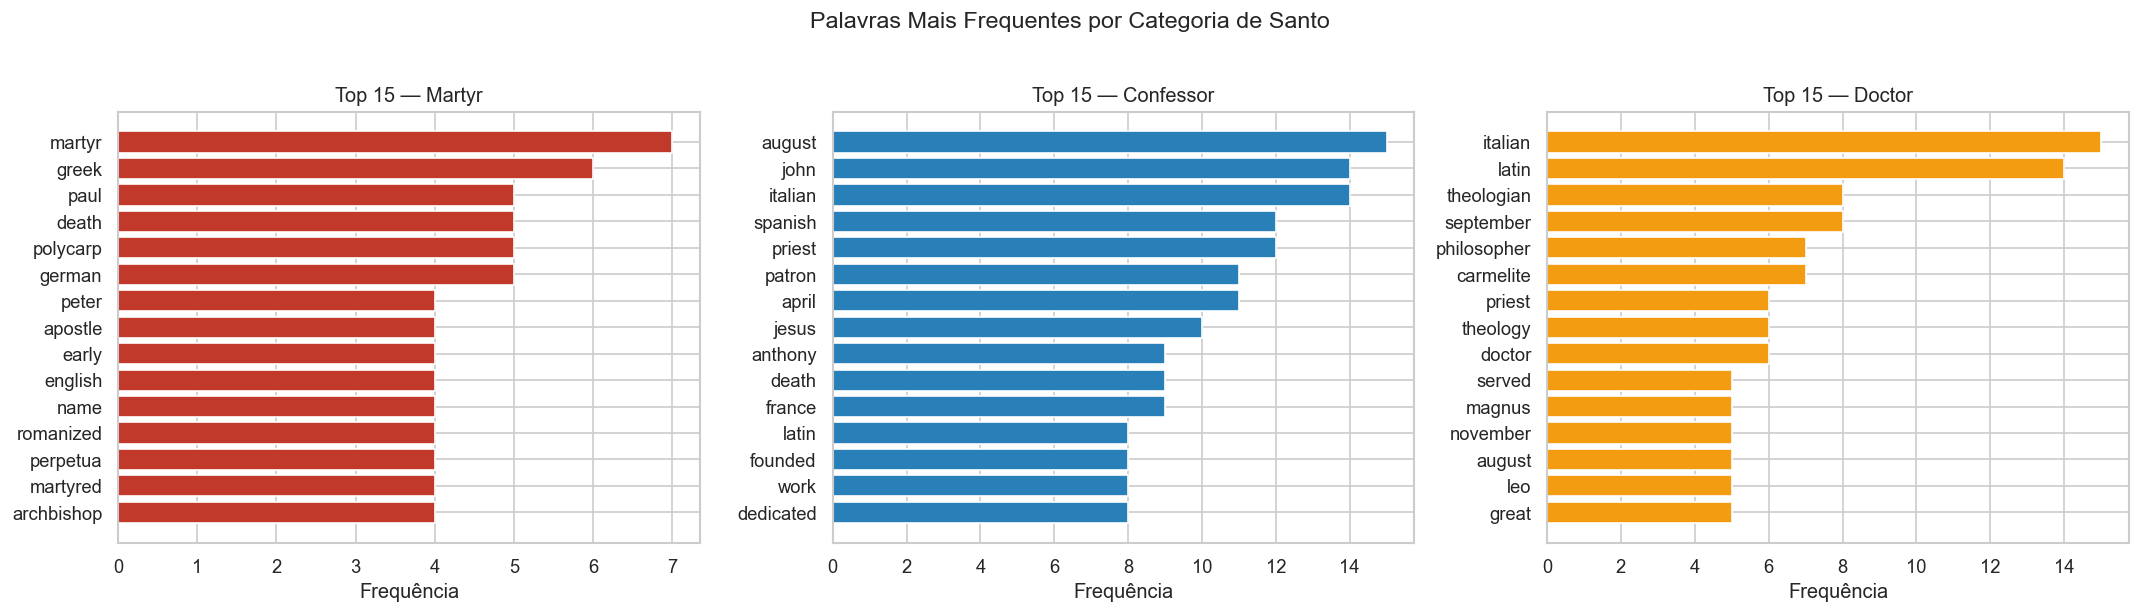

In [4]:
# Palavras mais frequentes por categoria
categorias_nlp = [c for c in ['Martyr', 'Confessor', 'Doctor'] if c in df_nlp['category'].values]

fig, axes = plt.subplots(1, len(categorias_nlp), figsize=(6 * len(categorias_nlp), 5))
if len(categorias_nlp) == 1:
    axes = [axes]

for ax, cat in zip(axes, categorias_nlp):
    textos_cat = ' '.join(df_nlp[df_nlp['category'] == cat]['texto_limpo'])
    palavras = Counter(textos_cat.split()).most_common(15)
    termos, freq = zip(*palavras) if palavras else ([], [])

    ax.barh(list(termos)[::-1], list(freq)[::-1], color=CORES_CAT.get(cat, '#95A5A6'))
    ax.set_title(f'Top 15 — {cat}', fontsize=12)
    ax.set_xlabel('Frequência')

plt.suptitle('Palavras Mais Frequentes por Categoria de Santo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / '06_freq_palavras.png', bbox_inches='tight')
plt.show()

## 3. Word Clouds por Categoria

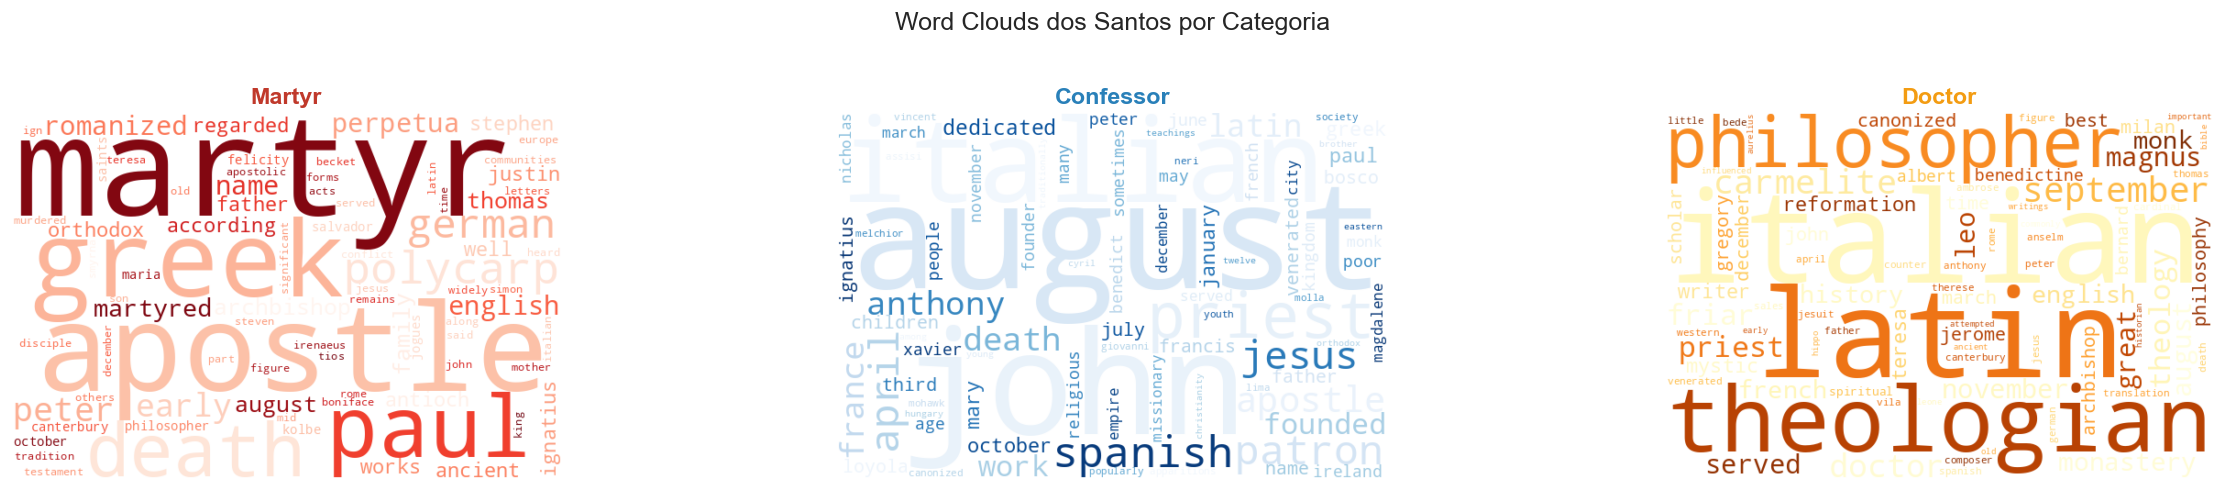

In [5]:
def gerar_wordcloud(texto, cor_fundo='white', colormap='Blues'):
    wc = WordCloud(
        width=600, height=400,
        background_color=cor_fundo,
        colormap=colormap,
        max_words=80,
        stopwords=STOPWORDS,
        collocations=False,
    )
    wc.generate(texto)
    return wc

colormaps = {'Martyr': 'Reds', 'Confessor': 'Blues', 'Doctor': 'YlOrBr', 'Virgin': 'Purples'}

fig, axes = plt.subplots(1, len(categorias_nlp), figsize=(7 * len(categorias_nlp), 4))
if len(categorias_nlp) == 1:
    axes = [axes]

for ax, cat in zip(axes, categorias_nlp):
    textos_cat = ' '.join(df_nlp[df_nlp['category'] == cat]['texto_limpo'])
    if textos_cat.strip():
        wc = gerar_wordcloud(textos_cat, colormap=colormaps.get(cat, 'Blues'))
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(cat, fontsize=14, color=CORES_CAT.get(cat, 'black'), fontweight='bold')

plt.suptitle('Word Clouds dos Santos por Categoria', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / '06_wordclouds.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. TF-IDF — Representação Vetorial

Matriz TF-IDF: (77, 300)
Vocabulário: 300 termos


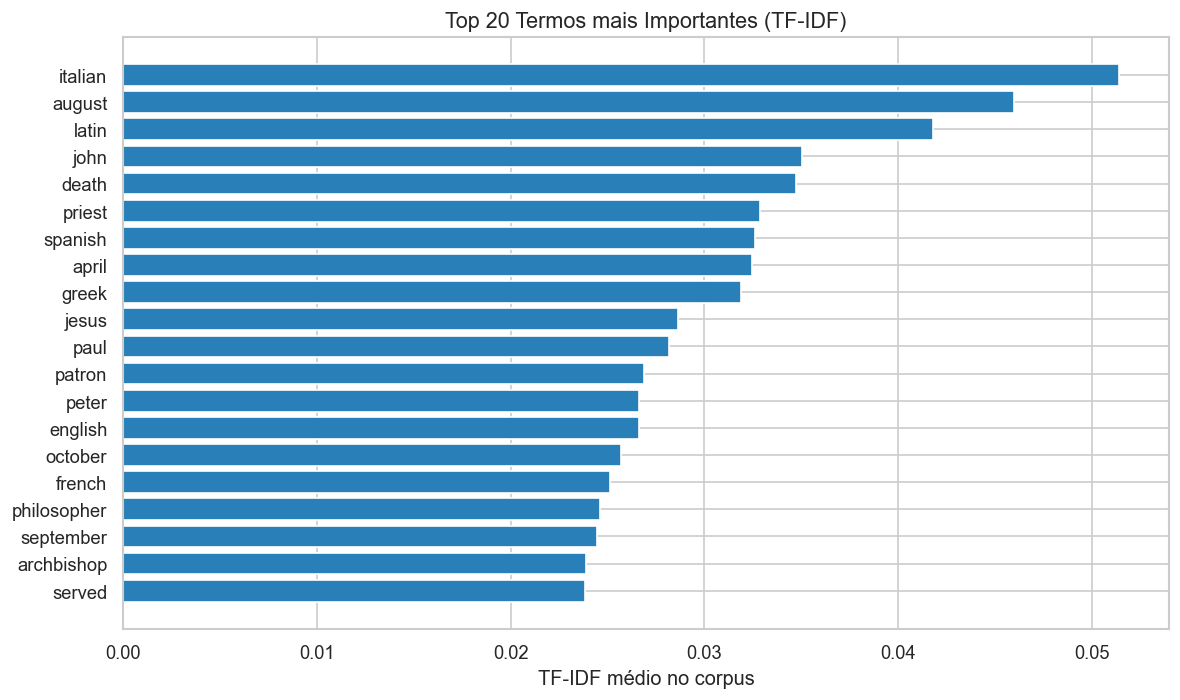

In [6]:
# TF-IDF: mede a importância de cada palavra no corpus
# TF = frequência no documento; IDF = penaliza palavras muito comuns
tfidf = TfidfVectorizer(
    max_features=300,
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2)  # inclui bigramas (ex: 'patron saint')
)

X_tfidf = tfidf.fit_transform(df_nlp['texto_limpo'])
print(f'Matriz TF-IDF: {X_tfidf.shape}')
print(f'Vocabulário: {len(tfidf.vocabulary_)} termos')

# Top termos por TF-IDF médio
scores_medios = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_idx = scores_medios.argsort()[-20:][::-1]
top_terms = np.array(tfidf.get_feature_names_out())[top_idx]
top_scores = scores_medios[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_terms[::-1], top_scores[::-1], color='#2980B9')
ax.set_xlabel('TF-IDF médio no corpus')
ax.set_title('Top 20 Termos mais Importantes (TF-IDF)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / '06_tfidf_top_terms.png', bbox_inches='tight')
plt.show()

## 5. Topic Modeling com LDA

LDA (Latent Dirichlet Allocation) descobre **tópicos temáticos** no corpus sem supervisão — cada tópico é uma distribuição de palavras.

In [7]:
# CountVectorizer para LDA (LDA usa contagens, não TF-IDF)
count_vec = CountVectorizer(max_features=200, stop_words='english', min_df=2)
X_counts  = count_vec.fit_transform(df_nlp['texto_limpo'])

N_TOPICS = 5
lda = LatentDirichletAllocation(
    n_components=N_TOPICS, random_state=42,
    max_iter=30, learning_method='batch'
)
lda.fit(X_counts)

# Mostrar palavras-chave de cada tópico
vocab = np.array(count_vec.get_feature_names_out())
nomes_topicos = [
    'Martirio/Perseguição', 'Vida Monástica', 'Missão/Apostolado',
    'Teologia/Escritos', 'Devoção/Caridade'
]

print('=== TÓPICOS DESCOBERTOS PELO LDA ===')
for i, (componente, nome) in enumerate(zip(lda.components_, nomes_topicos)):
    top10 = vocab[componente.argsort()[-10:][::-1]]
    print(f'\nTópico {i} — {nome}:')
    print('  ' + ', '.join(top10))

=== TÓPICOS DESCOBERTOS PELO LDA ===

Tópico 0 — Martirio/Perseguição:
  jesus, carmelite, death, teresa, october, august, ignatius, loyola, spanish, family

Tópico 1 — Vida Monástica:
  spanish, august, priest, canterbury, work, italian, thomas, june, french, archbishop

Tópico 2 — Missão/Apostolado:
  john, latin, march, nicholas, juan, gregory, december, orthodox, milan, april

Tópico 3 — Teologia/Escritos:
  anthony, english, paul, german, ireland, patron, august, history, september, early

Tópico 4 — Devoção/Caridade:
  italian, greek, latin, theology, priest, philosopher, august, dedicated, bosco, november


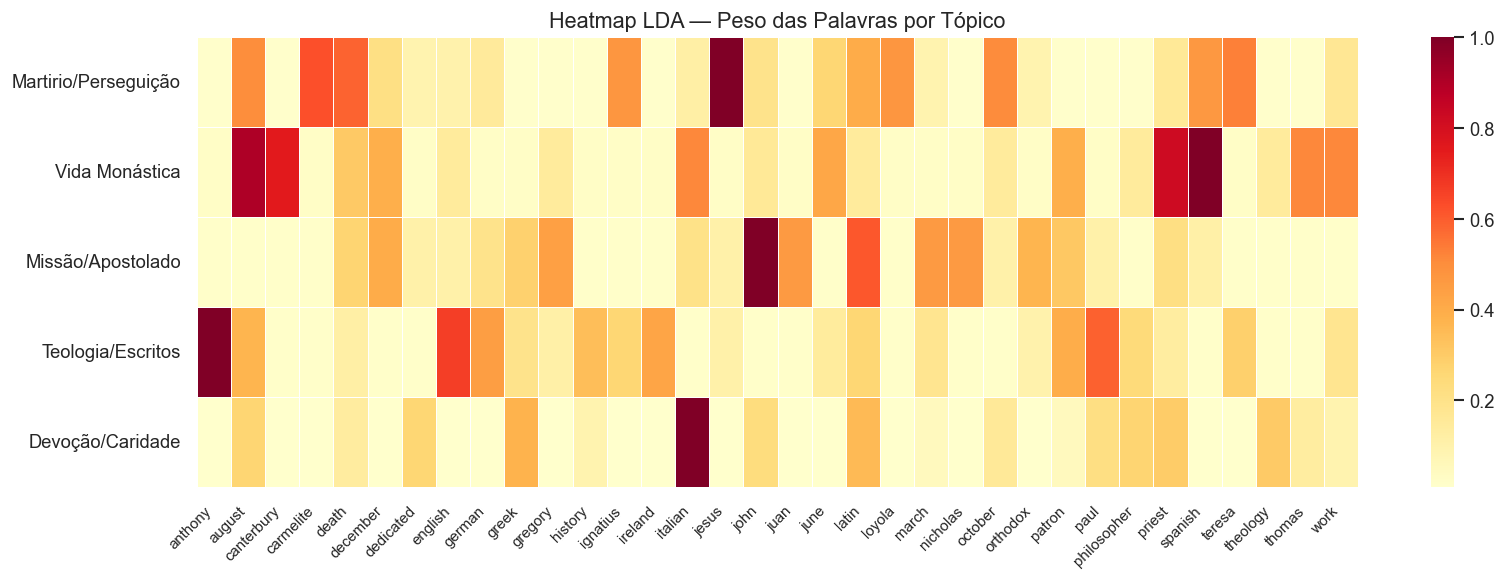

In [8]:
# Heatmap: top palavras por tópico
top_n = 8
fig, ax = plt.subplots(figsize=(14, 5))

dados_hm = []
all_top_words = set()
for comp in lda.components_:
    top_idx = comp.argsort()[-top_n:][::-1]
    all_top_words.update(vocab[top_idx])

all_top_words = sorted(all_top_words)
word_idx = {w: np.where(vocab == w)[0][0] for w in all_top_words if w in vocab}

matrix = np.array([[comp[word_idx[w]] for w in all_top_words if w in word_idx]
                    for comp in lda.components_])

# Normalizar linhas
matrix_norm = matrix / (matrix.max(axis=1, keepdims=True) + 1e-9)

colunas_hm = [w for w in all_top_words if w in word_idx]
sns.heatmap(
    matrix_norm,
    xticklabels=colunas_hm,
    yticklabels=nomes_topicos,
    cmap='YlOrRd', ax=ax, linewidths=0.3
)
ax.set_title('Heatmap LDA — Peso das Palavras por Tópico', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(FIGS / '06_lda_heatmap.png', bbox_inches='tight')
plt.show()

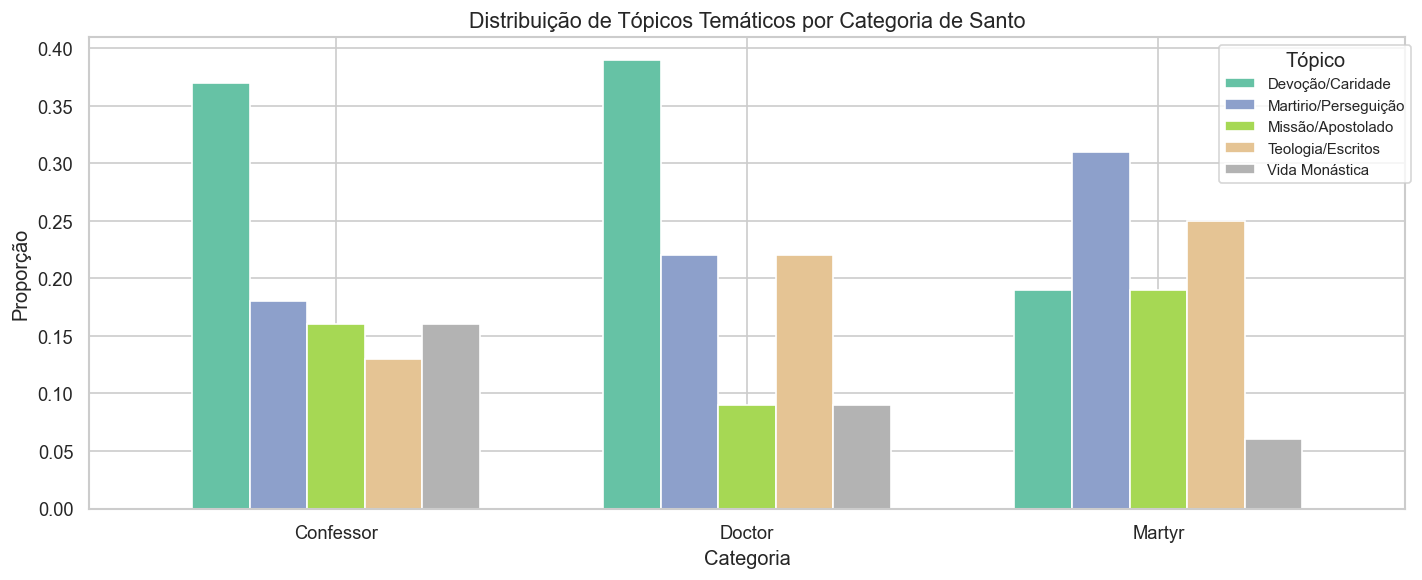

In [9]:
# Distribuição de tópicos por categoria
doc_topics  = lda.transform(X_counts)
topico_dom  = doc_topics.argmax(axis=1)
df_nlp['topico_dominante'] = topico_dom
df_nlp['topico_nome']      = df_nlp['topico_dominante'].map(dict(enumerate(nomes_topicos)))

cross = pd.crosstab(df_nlp['category'], df_nlp['topico_nome'], normalize='index').round(2)

fig, ax = plt.subplots(figsize=(12, 5))
cross.plot(kind='bar', ax=ax, colormap='Set2', width=0.7)
ax.set_xlabel('Categoria')
ax.set_ylabel('Proporção')
ax.set_title('Distribuição de Tópicos Temáticos por Categoria de Santo', fontsize=13)
ax.legend(title='Tópico', bbox_to_anchor=(1.01, 1), fontsize=9)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(FIGS / '06_topicos_por_categoria.png', bbox_inches='tight')
plt.show()

## 6. Análise de Sentimento com TextBlob

In [10]:
def analisar_sentimento(texto):
    blob = TextBlob(str(texto))
    return pd.Series({
        'polaridade':    blob.sentiment.polarity,     # -1 (negativo) a +1 (positivo)
        'subjetividade': blob.sentiment.subjectivity  # 0 (objetivo) a 1 (subjetivo)
    })

sentimentos = df_nlp['wikipedia_summary'].apply(analisar_sentimento)
df_nlp[['polaridade', 'subjetividade']] = sentimentos

print('Sentimento médio por categoria:')
print(df_nlp.groupby('category')[['polaridade', 'subjetividade']].mean().round(3))

Sentimento médio por categoria:
           polaridade  subjetividade
category                            
Confessor       0.062          0.304
Doctor          0.126          0.314
Martyr          0.032          0.226


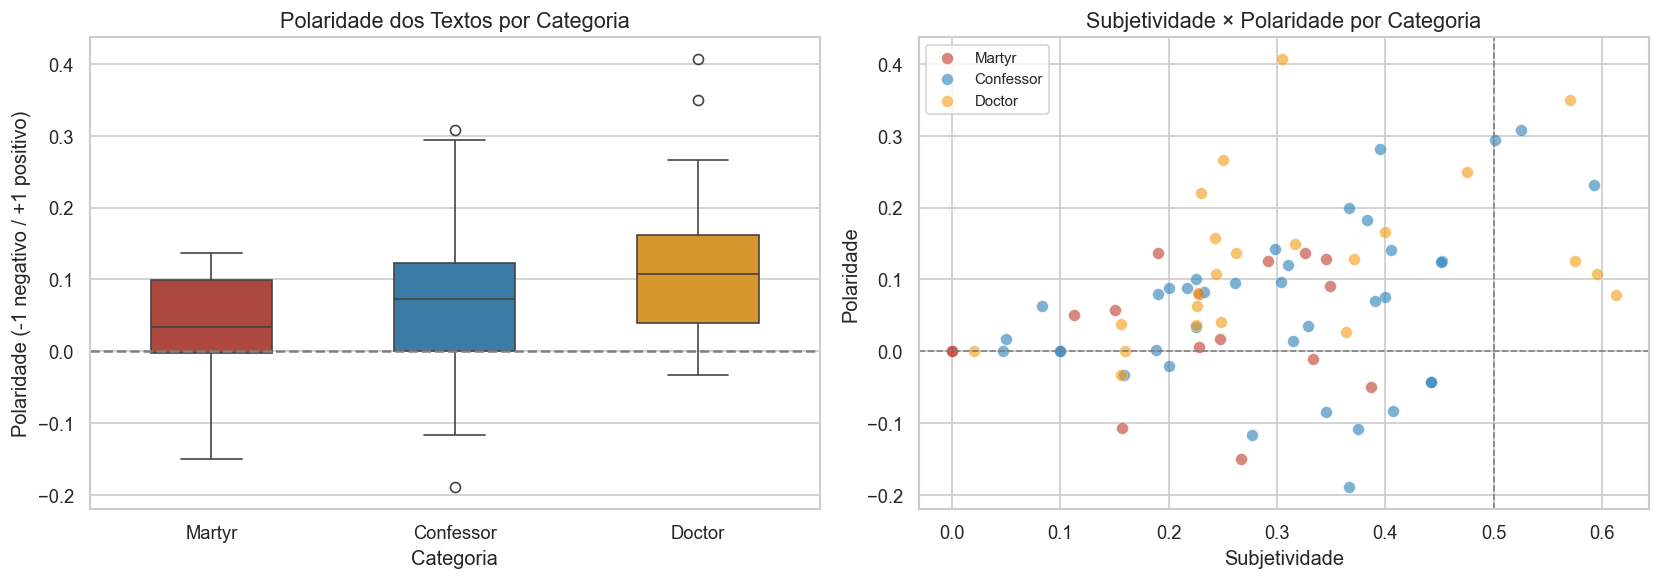

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot de polaridade por categoria
ordem = df_nlp.groupby('category')['polaridade'].median().sort_values().index
sns.boxplot(data=df_nlp, x='category', y='polaridade',
            order=ordem, palette=CORES_CAT, ax=axes[0], width=0.5)
axes[0].axhline(0, color='gray', linestyle='--', lw=1.5)
axes[0].set_title('Polaridade dos Textos por Categoria', fontsize=13)
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Polaridade (-1 negativo / +1 positivo)')

# Scatter polaridade × subjetividade
for cat, cor in CORES_CAT.items():
    mask = df_nlp['category'] == cat
    if mask.sum() > 0:
        axes[1].scatter(df_nlp.loc[mask,'subjetividade'], df_nlp.loc[mask,'polaridade'],
                        c=cor, label=cat, alpha=0.6, s=50, edgecolors='white', linewidths=0.3)
axes[1].set_xlabel('Subjetividade')
axes[1].set_ylabel('Polaridade')
axes[1].set_title('Subjetividade × Polaridade por Categoria', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].axhline(0, color='gray', linestyle='--', lw=1)
axes[1].axvline(0.5, color='gray', linestyle='--', lw=1)

plt.tight_layout()
plt.savefig(FIGS / '06_sentimento.png', bbox_inches='tight')
plt.show()

## 7. t-SNE sobre Embeddings de Texto

In [12]:
X_tfidf_dense = X_tfidf.toarray()

perp = min(30, len(X_tfidf_dense) // 5)
tsne_text = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000, verbose=0)
X_tsne_text = tsne_text.fit_transform(X_tfidf_dense)

df_nlp['tsne_txt1'] = X_tsne_text[:, 0]
df_nlp['tsne_txt2'] = X_tsne_text[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))
for cat, cor in CORES_CAT.items():
    mask = df_nlp['category'] == cat
    if mask.sum() > 0:
        ax.scatter(df_nlp.loc[mask,'tsne_txt1'], df_nlp.loc[mask,'tsne_txt2'],
                   c=cor, label=f'{cat} (n={mask.sum()})',
                   alpha=0.75, s=70, edgecolors='white', linewidths=0.5)

# Anotar alguns santos famosos
destaques_nlp = ['Thomas Aquinas', 'Francis of Assisi', 'Teresa of Avila',
                 'John Paul II', 'Augustine of Hippo']
for _, row in df_nlp[df_nlp['name'].isin(destaques_nlp)].iterrows():
    ax.annotate(row['name'].split()[-1],
                xy=(row['tsne_txt1'], row['tsne_txt2']),
                xytext=(6, 4), textcoords='offset points', fontsize=8)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE — Similaridade Textual dos Resumos dos Santos\n(pontos próximos = textos semelhantes)',
             fontsize=13, pad=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIGS / '06_tsne_texto.png', bbox_inches='tight')
plt.show()

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## 8. Resumo Final do Projeto

In [ ]:
import os

figuras = list(FIGS.glob('*.png')) + list(FIGS.glob('*.html'))

print('=' * 60)
print('PROJETO DATA SCIENCE DOS SANTOS CATÓLICOS')
print('Resumo final')
print('=' * 60)
print(f'\n📊 Total de santos analisados: {len(df)}')
print(f'📝 Santos com texto NLP:       {len(df_nlp)}')
print(f'🗺  Países únicos:              {df["origin_country"].nunique()}')

if 'years_to_canonization' in df.columns:
    med = df[df['years_to_canonization'].between(0,800)]['years_to_canonization'].median()
    print(f'⏱  Mediana anos até canonização: {med:.0f} anos')

print(f'\n🖼  Gráficos gerados: {len(figuras)}')
for fig in sorted(figuras):
    print(f'   {fig.name}')

print('\n✅ Projeto concluído!')
print(f'   Veja todos os gráficos em: outputs/figures/')

---

## O que você aprendeu neste projeto?

| Técnica | Notebook | Conceito-chave |
|---|---|---|
| Web scraping | 01 | `pd.read_html`, Wikipedia API |
| Data wrangling | 02 | `pandas`, limpeza, derivação de colunas |
| EDA | 03 | `seaborn`, `matplotlib`, `plotly` |
| K-Means | 04 | Clustering, elbow method, silhouette |
| PCA + t-SNE | 04 | Redução de dimensionalidade |
| Random Forest | 05 | Classificação supervisionada |
| Feature Importance | 05 | Interpretabilidade de modelos |
| TF-IDF | 06 | Representação vetorial de texto |
| LDA | 06 | Topic modeling não-supervisionado |
| Sentimento | 06 | NLP básico com TextBlob |

**Próximos passos sugeridos:**
- Usar embeddings de linguagem (BERT, sentence-transformers) em vez de TF-IDF
- Construir um chatbot que responde como um santo específico
- Criar um dashboard interativo com Streamlit ou Dash
- Expandir o dataset com mais santos usando outras fontes